In [1]:
import squidpy as sq
import anndata as adata
import mudata as md
import muon as mu
import scanpy as sc
from omics_topic.models.amortizedLDA import MultimodalAmortizedLDA

/scratch/fcaretti/omics_topic_uv/lib/python3.12/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/scratch/fcaretti/omics_topic_uv/lib/python3.12/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/scratch/fcaretti/omics_topic_uv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autono

In [2]:
import zarr
print(zarr.__version__)

3.1.5


In [3]:
adata = sq.datasets.visium_hne_adata()  # H&E-stained Visium section

In [4]:
adata.X = adata.raw.X

In [5]:
adata.obsp['connectivities']

<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 53328 stored elements and shape (2688, 2688)>

In [6]:
MultimodalAmortizedLDA.setup_anndata(adata, spatial_key="connectivities")

In [7]:
import scanpy as sc
from omics_topic.models.amortizedLDA import MultimodalAmortizedLDA

model = MultimodalAmortizedLDA(
    adata,
    n_inputs_modalities=[adata.n_vars],
    likelihoods=["multinomial"],
    n_topics=10,
    n_hidden=64,
)

print("spatial flag:", model.spatial)                             # should be True
print("use_gcn:", model.module.guide.use_gcn)                     # should be True
print("adjacency set:", model.module.guide.adjacency is not None) # True
print("gcn encoders:", model.module.guide.gcn_encoders is not None)


spatial flag: True
use_gcn: True
adjacency set: True
gcn encoders: True


In [8]:
model.train(
    max_epochs=30,
    batch_size=adata.n_obs,  # full batch
    train_size=1.0,          # use all cells
    validation_size=0,       # no val subset
    log_every_n_steps=1,     # optional
)


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/scratch/fcaretti/omics_topic_uv/lib/python3.12/site-packages/lightning/pytorch/trainer/configuration_validator.py:68: You passed in a `val_dataloader` but have no `validation_step`. Skipping val loop.
You are using a CUDA device ('NVIDIA A100-PCIE-40GB') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/scratch/fcaretti/omics_topic_uv/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11

Epoch 2/30:   3%|▎         | 1/30 [00:00<00:10,  2.85it/s, v_num=1]

/scratch/fcaretti/omics_topic_uv/lib/python3.12/site-packages/pyro/primitives.py:478: UserWarning: 0 was not registered in the param store because requires_grad=False. You can silence this warning by calling my_module.train(False)
  warnings.warn(
/scratch/fcaretti/omics_topic_uv/lib/python3.12/site-packages/pyro/util.py:365: UserWarning: Found plate statements in guide but not model: {'topics_0'}
  warnings.warn(


Epoch 3/30:   7%|▋         | 2/30 [00:00<00:07,  3.58it/s, v_num=1, elbo_train=8.65e+8]

/scratch/fcaretti/omics_topic_uv/lib/python3.12/site-packages/pyro/primitives.py:478: UserWarning: 0 was not registered in the param store because requires_grad=False. You can silence this warning by calling my_module.train(False)
  warnings.warn(
/scratch/fcaretti/omics_topic_uv/lib/python3.12/site-packages/pyro/util.py:365: UserWarning: Found plate statements in guide but not model: {'topics_0'}
  warnings.warn(


...

Epoch 30/30:  97%|█████████▋| 29/30 [00:06<00:00,  4.70it/s, v_num=1, elbo_train=8.73e+8]

/scratch/fcaretti/omics_topic_uv/lib/python3.12/site-packages/pyro/primitives.py:478: UserWarning: 0 was not registered in the param store because requires_grad=False. You can silence this warning by calling my_module.train(False)
  warnings.warn(
/scratch/fcaretti/omics_topic_uv/lib/python3.12/site-packages/pyro/util.py:365: UserWarning: Found plate statements in guide but not model: {'topics_0'}
  warnings.warn(


Epoch 30/30: 100%|██████████| 30/30 [00:06<00:00,  4.69it/s, v_num=1, elbo_train=8.56e+8]

/scratch/fcaretti/omics_topic_uv/lib/python3.12/site-packages/pyro/primitives.py:478: UserWarning: 0 was not registered in the param store because requires_grad=False. You can silence this warning by calling my_module.train(False)
  warnings.warn(
/scratch/fcaretti/omics_topic_uv/lib/python3.12/site-packages/pyro/util.py:365: UserWarning: Found plate statements in guide but not model: {'topics_0'}
  warnings.warn(
`Trainer.fit` stopped: `max_epochs=30` reached.


Epoch 30/30: 100%|██████████| 30/30 [00:06<00:00,  4.57it/s, v_num=1, elbo_train=8.56e+8]


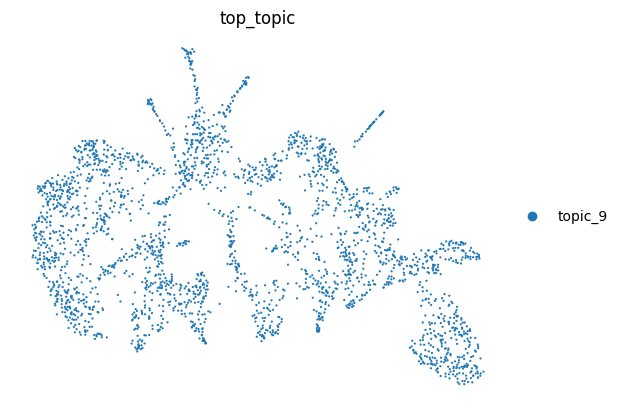

In [9]:
import numpy as np
import pandas as pd
import scanpy as sc

# 1) Topic proportions per cell, visualized on UMAP
theta = model.get_latent_representation(adata, batch_size=adata.n_obs)  # full batch
adata.obsm["X_topic"] = theta.values
adata.obs["top_topic"] = theta.idxmax(axis=1)

sc.pl.umap(adata, color=["top_topic"], frameon=False, s=10)

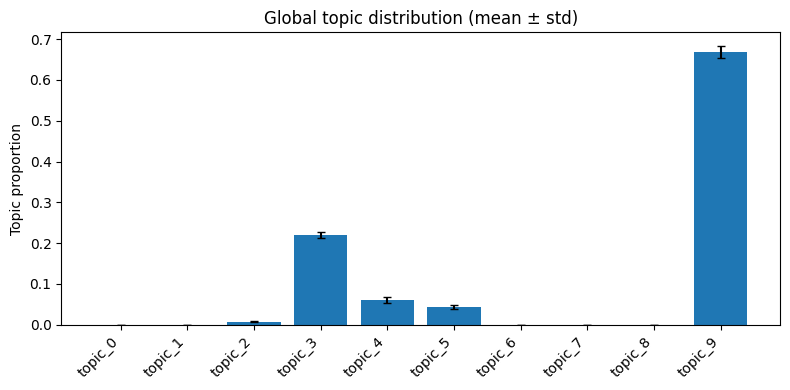

In [10]:
import matplotlib.pyplot as plt
import numpy as np

theta = model.get_latent_representation(adata, batch_size=adata.n_obs)  # full batch for GCN

means = theta.mean(axis=0)
stds = theta.std(axis=0)

plt.figure(figsize=(8, 4))
plt.bar(np.arange(len(means)), means.values, yerr=stds.values, capsize=3)
plt.xticks(np.arange(len(means)), means.index, rotation=45, ha="right")
plt.ylabel("Topic proportion")
plt.title("Global topic distribution (mean ± std)")
plt.tight_layout()
plt.show()



##

In [16]:
import scanpy as sc
from omics_topic.models.amortizedLDA import MultimodalAmortizedLDA

adata_nos = adata.copy()
# remove spatial metadata so spatial flag becomes False
adata_nos.uns.pop("_spatial_graph", None)
adata_nos.uns.pop("_spatial_graphs", None)

# register without spatial_key; keep counts layer if you set it
MultimodalAmortizedLDA.setup_anndata(adata_nos)

model_nos = MultimodalAmortizedLDA(
    adata_nos,
    n_inputs_modalities=[adata_nos.n_vars],
    likelihoods=["gamma_poisson"],
    n_topics=10,
    n_hidden=64,
)

print("spatial flag:", model_nos.spatial)         # False
print("use_gcn:", model_nos.module.guide.use_gcn) # False

model_nos.train(max_epochs=30, batch_size=128, train_size=1.0, validation_size=0, log_every_n_steps=1)

theta_nos = model_nos.get_latent_representation(adata_nos)  # default batching fine



GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/scratch/fcaretti/omics_topic_uv/lib/python3.12/site-packages/lightning/pytorch/trainer/configuration_validator.py:68: You passed in a `val_dataloader` but have no `validation_step`. Skipping val loop.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/scratch/fcaretti/omics_topic_uv/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=111` in the `DataLoader` to improve performance.


spatial flag: False
use_gcn: False
Epoch 1/30:   0%|          | 0/30 [00:00<?, ?it/s]

/scratch/fcaretti/omics_topic_uv/lib/python3.12/site-packages/pyro/primitives.py:478: UserWarning: 0 was not registered in the param store because requires_grad=False. You can silence this warning by calling my_module.train(False)
  warnings.warn(
/scratch/fcaretti/omics_topic_uv/lib/python3.12/site-packages/pyro/util.py:365: UserWarning: Found plate statements in guide but not model: {'topics_0'}
  warnings.warn(


Epoch 2/30:   3%|▎         | 1/30 [00:00<00:12,  2.28it/s, v_num=1]

/scratch/fcaretti/omics_topic_uv/lib/python3.12/site-packages/pyro/primitives.py:478: UserWarning: 0 was not registered in the param store because requires_grad=False. You can silence this warning by calling my_module.train(False)
  warnings.warn(
/scratch/fcaretti/omics_topic_uv/lib/python3.12/site-packages/pyro/util.py:365: UserWarning: Found plate statements in guide but not model: {'topics_0'}
  warnings.warn(


...

Epoch 30/30:  97%|█████████▋| 29/30 [00:11<00:00,  2.44it/s, v_num=1, elbo_train=1.21e+8]

/scratch/fcaretti/omics_topic_uv/lib/python3.12/site-packages/pyro/primitives.py:478: UserWarning: 0 was not registered in the param store because requires_grad=False. You can silence this warning by calling my_module.train(False)
  warnings.warn(
/scratch/fcaretti/omics_topic_uv/lib/python3.12/site-packages/pyro/util.py:365: UserWarning: Found plate statements in guide but not model: {'topics_0'}
  warnings.warn(


Epoch 30/30: 100%|██████████| 30/30 [00:12<00:00,  2.45it/s, v_num=1, elbo_train=1.2e+8] 

`Trainer.fit` stopped: `max_epochs=30` reached.


Epoch 30/30: 100%|██████████| 30/30 [00:12<00:00,  2.44it/s, v_num=1, elbo_train=1.2e+8]


INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             


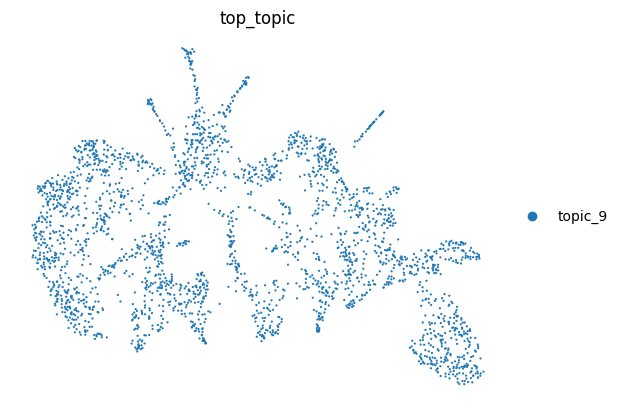

In [17]:
import numpy as np
import pandas as pd
import scanpy as sc

# 1) Topic proportions per cell, visualized on UMAP
theta = model.get_latent_representation(adata, batch_size=adata.n_obs)  # full batch
adata.obsm["X_topic"] = theta.values
adata.obs["top_topic"] = theta.idxmax(axis=1)

sc.pl.umap(adata, color=["top_topic"], frameon=False, s=10)

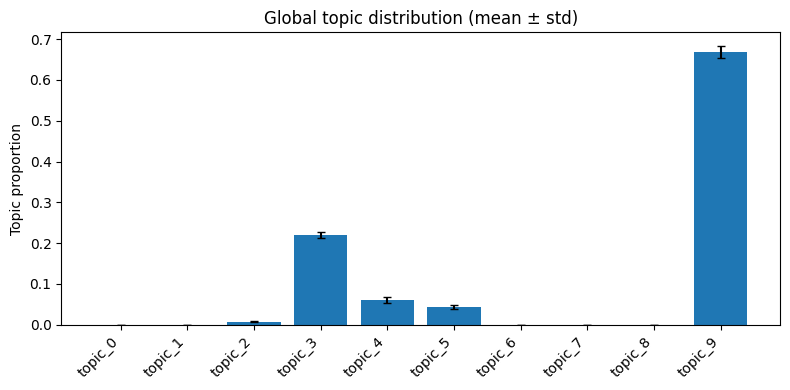

In [18]:
import matplotlib.pyplot as plt
import numpy as np

theta = model.get_latent_representation(adata, batch_size=adata.n_obs)  # full batch for GCN

means = theta.mean(axis=0)
stds = theta.std(axis=0)

plt.figure(figsize=(8, 4))
plt.bar(np.arange(len(means)), means.values, yerr=stds.values, capsize=3)
plt.xticks(np.arange(len(means)), means.index, rotation=45, ha="right")
plt.ylabel("Topic proportion")
plt.title("Global topic distribution (mean ± std)")
plt.tight_layout()
plt.show()

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/scratch/fcaretti/omics_topic_uv/lib/python3.12/site-packages/lightning/pytorch/trainer/configuration_validator.py:68: You passed in a `val_dataloader` but have no `validation_step`. Skipping val loop.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/scratch/fcaretti/omics_topic_uv/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=111` in the `DataLoader` to improve performance.


Epoch 30/30: 100%|██████████| 30/30 [00:11<00:00,  2.67it/s, v_num=1, elbo_train=7.58e+8]

`Trainer.fit` stopped: `max_epochs=30` reached.


Epoch 30/30: 100%|██████████| 30/30 [00:11<00:00,  2.53it/s, v_num=1, elbo_train=7.58e+8]
Global topic means:
                  gcn      scvi
topic_0  4.553669e-18  0.088369
topic_1  2.833142e-09  0.113301
topic_2  7.819946e-03  0.082352
topic_3  2.198149e-01  0.102245
topic_4  6.087055e-02  0.118453
topic_5  4.289779e-02  0.081531
topic_6  5.167992e-08  0.107503
topic_7  3.542286e-17  0.079101
topic_8  1.452808e-11  0.116320
topic_9  6.685973e-01  0.110824

Topic-wise correlation (by column name match):
topic_0    0.019099
topic_1    0.133011
topic_2    0.025897
topic_3   -0.347000
topic_4    0.574749
topic_5    0.063823
topic_6   -0.101249
topic_7   -0.069451
topic_8   -0.019877
topic_9    0.279952
dtype: float64


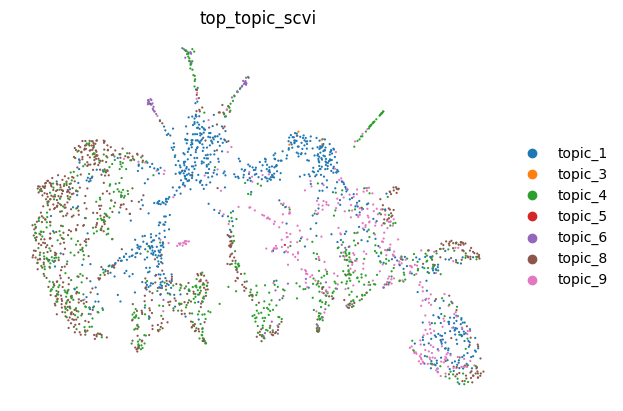

In [19]:
import scanpy as sc
from scvi.model import AmortizedLDA as ScviAmortizedLDA
from omics_topic.models.amortizedLDA import MultimodalAmortizedLDA

# Assume `adata` already has adata.layers["counts"] with integers
adata_base = adata.copy()
ScviAmortizedLDA.setup_anndata(adata_base)

# Train scvi-tools AmortizedLDA (no spatial support)
scvi_model = ScviAmortizedLDA(adata_base, n_topics=10, n_hidden=64)
scvi_model.train(max_epochs=30, batch_size=128, train_size=1.0, validation_size=0)

theta_scvi = scvi_model.get_latent_representation(adata_base)  # ndarray (cells × topics)

# Your GCN model outputs
theta_gcn = model.get_latent_representation(adata, batch_size=adata.n_obs)  # full-batch for adjacency

# Compare topic means and correlation
import pandas as pd
import numpy as np

df_scvi = pd.DataFrame(theta_scvi, index=adata_base.obs_names, columns=[f"topic_{k}" for k in range(theta_scvi.shape[1])])
df_gcn = theta_gcn  # already DataFrame from your model

print("Global topic means:")
print(pd.DataFrame({"gcn": df_gcn.mean(0), "scvi": df_scvi.mean(0)}))

print("\nTopic-wise correlation (by column name match):")
print(df_gcn.corrwith(df_scvi, axis=0))

# Optional: UMAP of scvi topics
adata_base.obsm["X_topic_scvi"] = df_scvi.values
adata_base.obs["top_topic_scvi"] = df_scvi.idxmax(axis=1)
sc.pl.umap(adata_base, color=["top_topic_scvi"], frameon=False, s=10)


INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        


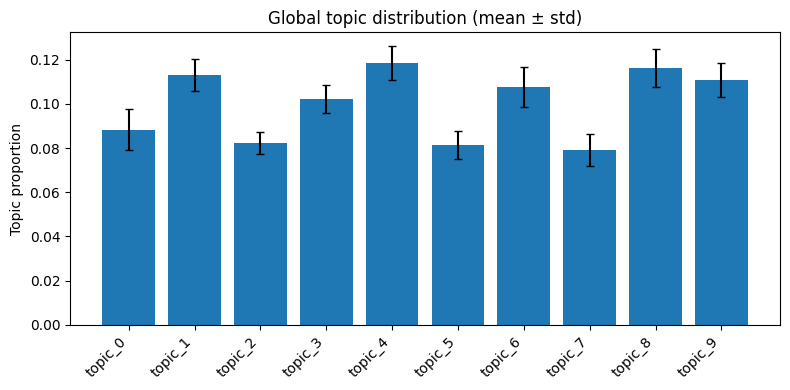

In [20]:
import matplotlib.pyplot as plt
import numpy as np

theta = scvi_model.get_latent_representation(adata, batch_size=adata.n_obs)  # full batch for GCN

means = theta.mean(axis=0)
stds = theta.std(axis=0)

plt.figure(figsize=(8, 4))
plt.bar(np.arange(len(means)), means.values, yerr=stds.values, capsize=3)
plt.xticks(np.arange(len(means)), means.index, rotation=45, ha="right")
plt.ylabel("Topic proportion")
plt.title("Global topic distribution (mean ± std)")
plt.tight_layout()
plt.show()